## 3. Übung
### Lineare Nachbarschaftsfilter
In dieser Übung werden Sie einen linearen Nachbarschaftsfilter auf einem Bild anwenden und
die Rahmenbedingungen eines Filters kennenlernen. Wenden Sie die linearen Filter auf das
Bild Lena.jpg an.

1. Lesen Sie das Kapitel 6 (Filter) aus dem Buch ”Digitale Bildverarbeitung”.
2. Implementieren Sie eine Funktion, die es erlaubt ein Bild (im sinnvollen Rahmen) mit
frei w¨ahlbaren Filtermasken zu falten.

```
• Prototyp: [ out image ] = filter(in image, filter, oﬀ)
– out image: Ergebnisbild (int) nach Faltung von in image mit filter
– filter: Filtermatrix (float)
– oﬀ: Oﬀset (int). Der Oﬀset, auch bekannt als stride, gibt an, um wie viele Pixel
die Filtermatrix verschoben wird. Bei einem oﬀset > , wird die Bildgr¨osse
deutlich verkleinert.
– 8-Bit Graustufenbilder als Eingangs- und Ausgangsdaten.
– Filtermatrix der Gr¨osse (NxN) mit N = (2K + 1), K = 1, 2, ...
– Beispielaufruf: filter(image, [1 1 1; 1 3 1; 1 1 1]/11, 1)
```

In [521]:
from matplotlib.pyplot import subplots
from skimage import io
import numpy as np
import matplotlib.pyplot as plt

image = io.imread('lena.jpg')

def rgb2gray(rgb):

    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b

    return gray

image_gray = rgb2gray(image)


Output = ((N-K) / S) + 1
```
N -> height/width
S -> off
K -> border removed by filter
```
K = distance from center of filter -> K = k // 2

In [522]:
def filter_1(in_image, kernel, off=1):
    # size of image
    h, w = in_image.shape
    fh, fw = kernel.shape

    # how far filter reaches around the pixel
    k = fh // 2

    # compute size of output image 2*K because you loose 2*K pixels on both sides
    out_h = (h - 2*k) // off + 1
    out_w = (w - 2*k) // off + 1

    # prepare output
    out_image = np.zeros((out_h, out_w), np.uint8)

    # for true convulsion flip the kernel matrix
    flip_kernel = np.flipud(np.fliplr(kernel))

    # apply filter
    for y in range(k, h-k, off):
        for x in range(k, w-k, off):
            region = in_image[y-k:y+k+1, x-k:x+k+1]
            filtered_region = np.sum(region*flip_kernel)

            out_y = (y-k) // off
            out_x = (x-k) // off
            out_image[out_y, out_x] = filtered_region

    return out_image

In [523]:
# define simple blur filter
simple_blur_filter = (1/9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

output = filter(image_gray, simple_blur_filter)

(np.float64(-0.5), np.float64(510.5), np.float64(510.5), np.float64(-0.5))

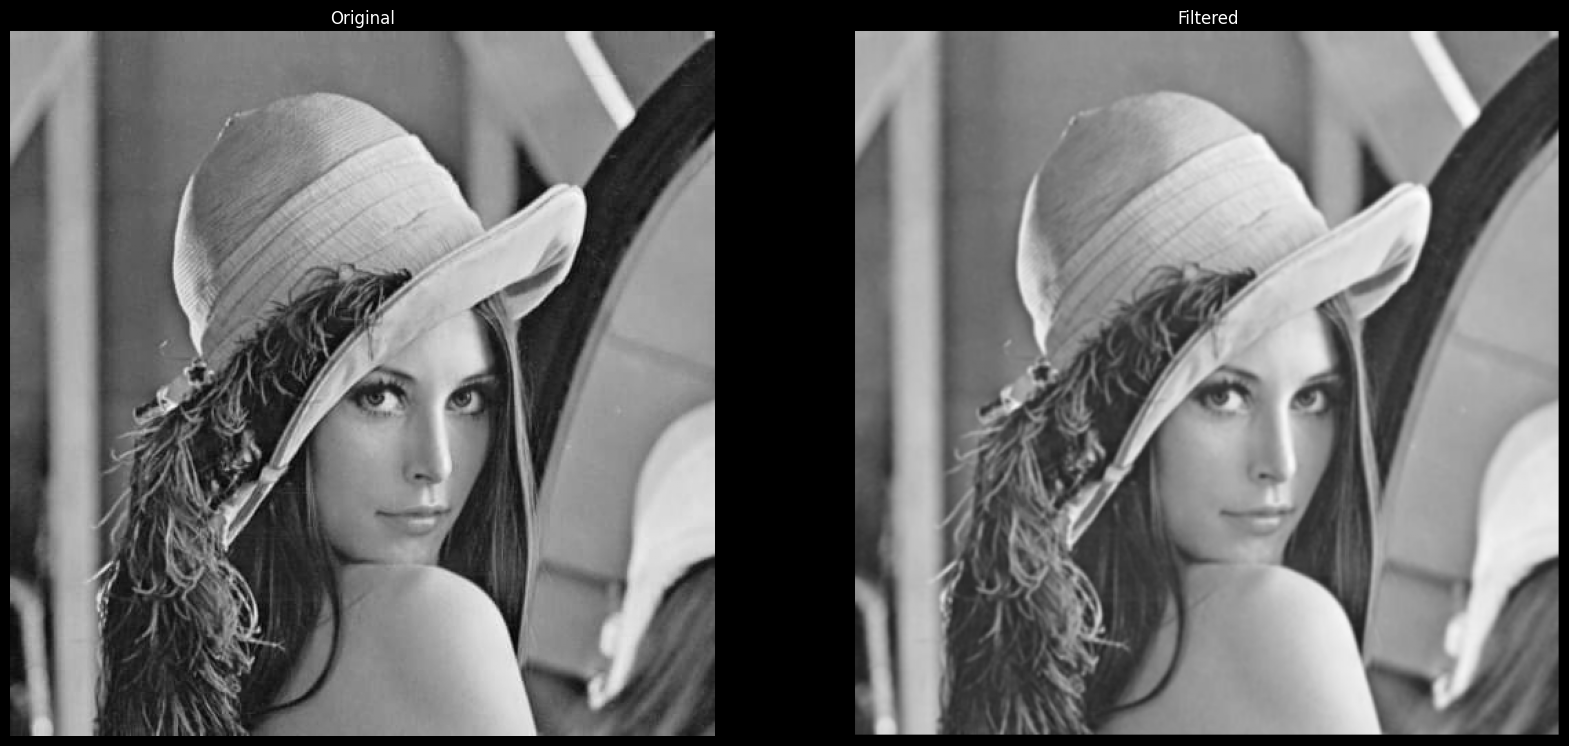

In [524]:
fig, axis = plt.subplots(1,2, figsize=(20,10))
axis[0].imshow(image_gray, cmap='gray')
axis[0].set_title('Original')
axis[0].axis('off')

axis[1].imshow(output, cmap='gray')
axis[1].set_title('Filtered')
axis[1].axis('off')

3. Erweitern Sie die Funktion filter() aus Aufgabe 2 um folgende Randbedingungen:
```
• min: Setzt Bildpunkte auf den minimalen Wert (0). Dies wird auch als zero padding
bezeichnet.
• max: Setzt Bildpunkte auf den maximalen Wert (255)
• continue: Setzt das Bild ausserhalb mit dem gleichen Pixelwert, wie das entsprechende
am nächsten liegende Randpixel, fort.
• Untersuchen Sie die Randbehandlungen auf ihr Verhalten bei Benutzung verschiedener
Filter.
• Prototyp: [ out image ] = filter(in image, filter, oﬀ, edge);
– edge: Parameter zur Auswahl der Randbehandlung (’min’) - String
```

1. min → zero padding

If pixel is outside image -> return 0

2. max → constant white padding

If pixel is outside image -> return 255

3. continue → edge replication

If pixel is outside image -> clamp to nearest valid pixel

In [525]:
def get_pixel(img, y, x, edge):
    h, w = img.shape

    # if x,y is inside image return normally
    if 0 <= y < h and 0 <= x < w:
        return img[y, x]

    # if pixel outside the image
    match edge:
        case 'min': # treat pixels as black
            return 0
        case 'max': # treat pixels as white
            return 255
        case 'continue': # extend the border = repeat edge pixels
            # if y/x to small clamp to valid range
            y = min(max(y, 0), h - 1)
            x = min(max(x, 0), w - 1)
            return img[y, x] # return nearest pixel
        case _:
            raise ValueError("Invalid edge")

In [526]:
def filter_2(in_image, kernel, off=1, edge='min'):
    h, w = in_image.shape
    fh, fw = kernel.shape

    k = fh // 2  # distance from center to border of kernel

    # output size matches FULL traversal with stride
    out_h = h // off
    out_w = w // off

    out_image = np.zeros((out_h, out_w), np.float32)

    # flip kernel for true convolution
    flip_kernel = np.flipud(np.fliplr(kernel))

    # traverse full image
    for y in range(0, h, off):
        for x in range(0, w, off):

            filtered_value = 0.0

            # apply kernel
            for i in range(-k, k + 1):
                for j in range(-k, k + 1):

                    pixel = get_pixel(in_image, y + i, x + j, edge)
                    weight = flip_kernel[i + k, j + k]

                    filtered_value += pixel * weight

            # map directly into output image
            out_image[y // off, x // off] = filtered_value

    return out_image

Filter definieren zur analyse

In [527]:
blur_filter = np.ones((11, 11)) / 215

sharpen_filter = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

edge_detection_filter = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

100.81396


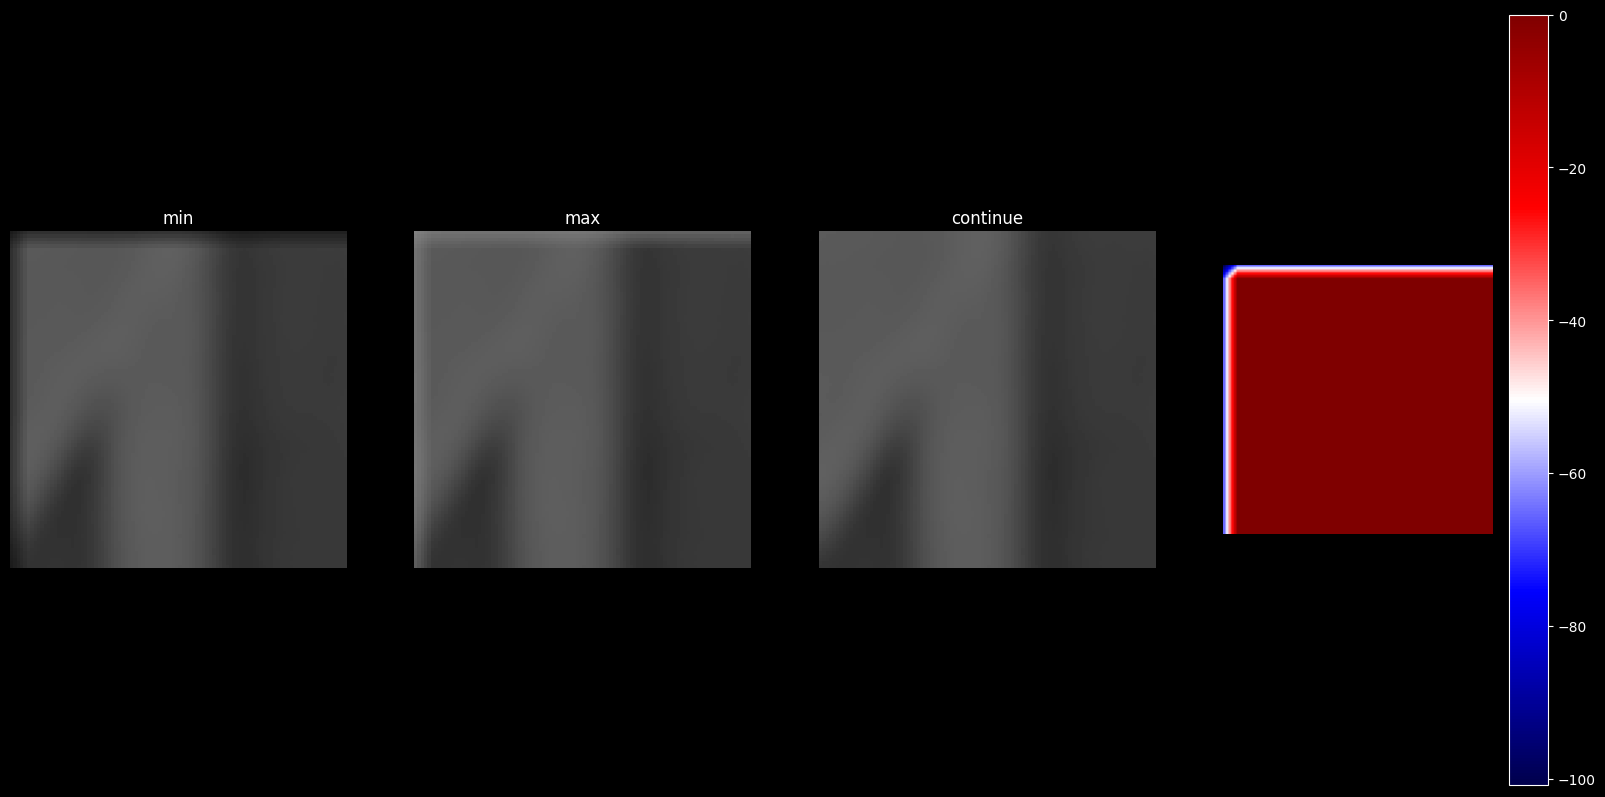

In [528]:
fig, axis = plt.subplots(1, 4, figsize=(20, 10))

img_blur_min = filter_2(image_gray, blur_filter, edge='min')
img_blur_max = filter_2(image_gray, blur_filter, edge='max')
img_blur_continue = filter_2(image_gray, blur_filter, edge='continue')

img_min = img_blur_min[:100, :100]
img_max = img_blur_max[:100, :100]
img_cont = img_blur_continue[:100, :100]

axis[0].imshow(img_min, cmap='gray', vmin=0, vmax=255)
axis[0].axis('off')
axis[0].set_title('min')

axis[1].imshow(img_max, cmap='gray', vmin=0, vmax=255)
axis[1].axis('off')
axis[1].set_title('max')

axis[2].imshow(img_cont, cmap='gray', vmin=0, vmax=255)
axis[2].axis('off')
axis[2].set_title('continue')

diff = img_min - img_max
im = axis[3].imshow(diff, cmap='seismic')
axis[3].axis('off')
plt.colorbar(im, ax=axis[3])

print(np.max(np.abs(diff)))

Text(0.5, 1.0, 'continue')

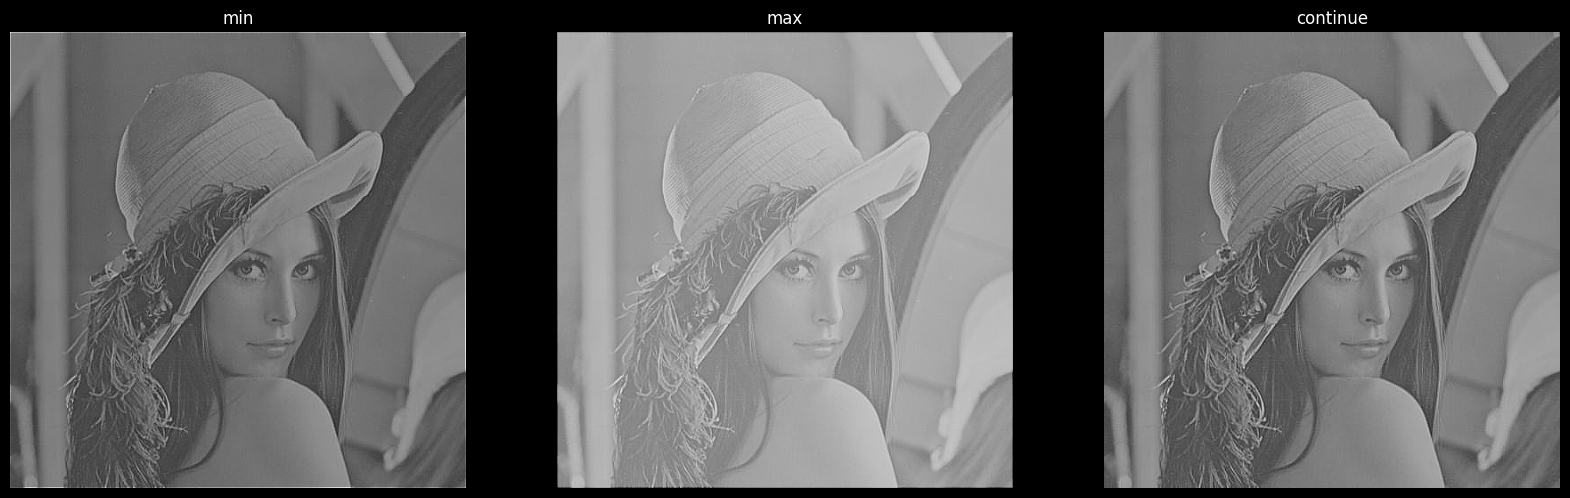

In [529]:
fig, axis = plt.subplots(1,3, figsize=(20,10))

img_min = filter_2(image_gray, sharpen_filter, edge='min')
axis[0].imshow(img_min, cmap='gray')
axis[0].axis('off')
axis[0].set_title('min')

img_max = filter_2(image_gray, sharpen_filter, edge='max')
axis[1].imshow(img_max, cmap='gray')
axis[1].axis('off')
axis[1].set_title('max')

img_continue = filter_2(image_gray, sharpen_filter, edge='continue')
axis[2].imshow(img_continue, cmap='gray')
axis[2].axis('off')
axis[2].set_title('continue')


Text(0.5, 1.0, 'continue')

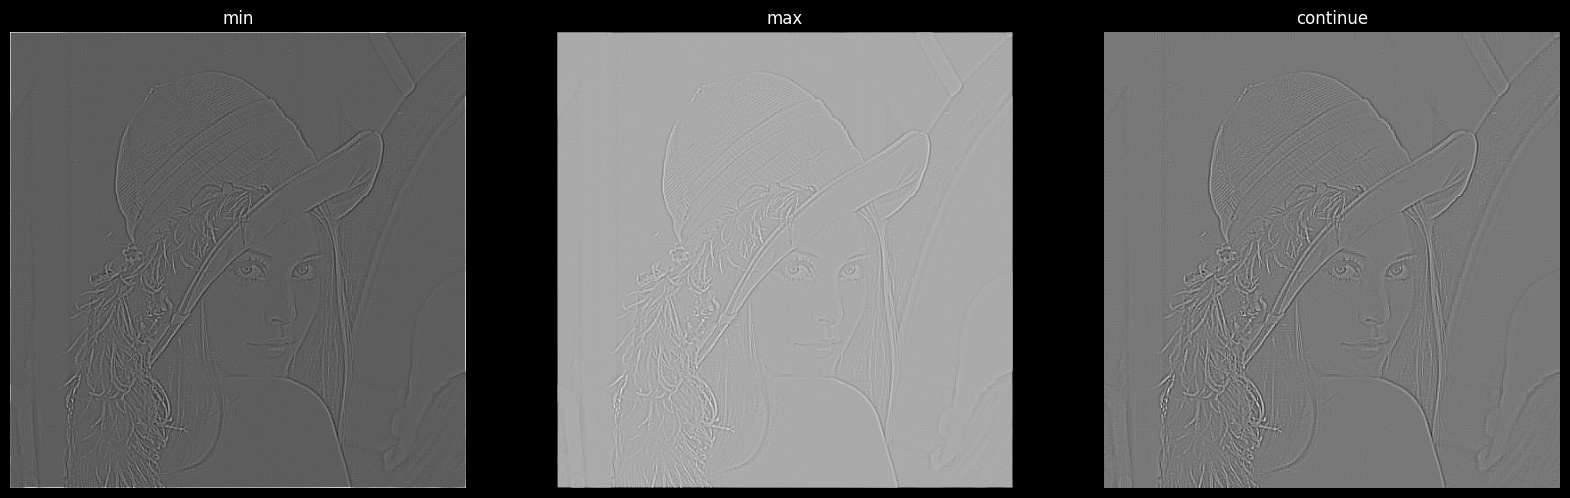

In [530]:
fig, axis = plt.subplots(1, 3, figsize=(20, 10))

img_min = filter_2(image_gray, edge_detection_filter, edge='min')
axis[0].imshow(img_min, cmap='gray')
axis[0].axis('off')
axis[0].set_title('min')

img_max = filter_2(image_gray, edge_detection_filter, edge='max')
axis[1].imshow(img_max, cmap='gray')
axis[1].axis('off')
axis[1].set_title('max')

img_continue = filter_2(image_gray, edge_detection_filter, edge='continue')
axis[2].imshow(img_continue, cmap='gray')
axis[2].axis('off')
axis[2].set_title('continue')


4. Beantworten Sie folgende Fragen:
```
a) Nennen Sie die Arten und Eigenschaften von linearen Filtern.
b) Was ist der Unterschied zwischen linearen und nichtlinearen Filtern?
```

a)
**Linearer filter** schaut für jeden pixel die nachbarpixel an und berechnet einen **gewichteten durchschnitt** der den pixel dann ersetzt

**Glättungsfilter** - alle gewichte sind positiv -> das bild wird weicher/unschärfer, rauschen wird reduziert, kanten werden ebenfalls unschärfer, also detailverlust

    - Box Filter:
        - gibt allen nachbarn das gleiche gewicht
        - resultiert in einer leichten unschärfe

    - Gaußfilter
        - gib zentrum ein stärkeres gewicht als den rändern
        - natrülichere unschärfe in alle richtungen

**Differenzfilter** - manche gewichte sind negativ -> filter sucht also unterschiede, wo das bild gleichmäßig ist passiert nichts, wo eine kante ist entsteht eine starke reaktion


**Eigenschaften von linearen filtern**

- Assoziativität: zwei filter nacheinander anwenden hat den gleichen effekt wie beide zu einem kombinieren und einmal anwenden. Man kann z.B. glätten und kanten suchen mit einem filter

b) **Unterschied zw. linearen und nicht linearen filtern**
Linear -> rechnet gewichtete summe der nachbarpixel -> jeder nachbar geht mit einem festen gewicht ein. d.h. dass kein pixel ignoriert werden kann, somit fließen auch extreme ausreißer mit ein

Nichtlinearer filter -> kein festes rechenverfahren, sondern eine entscheidung basierend auf den werten. beim medianfilter zum beispiel werden die werte sortiert und die mittlere genommen. beim minimum filter nimmt man einfach en kleinsten wert

**=>warum wichtig:** z.B. 8 pixel haben den wert 20 und ein pixel den wert 250

- linear -> 250er geht in die summe mit ein und verschiebt den durchschnitt
- nicht linear -> 250 landet nach dem sortieren ganz am ende und hat somit keinen einfluss

### Lineare Nachbarschaftsfilter

2. Implementieren Sie den Medianfilter.

```
- Prototyp: out image = medianFilter(in image, filtersize, oﬀset)
- out image: Ergebnisbild nach Faltung von in image mit filter
- in image: Eingangbild (int); 8-Bit Graustufenbilder
- filtersize: Filtergrösse (int); Grösse (NxN) mit N = (2K + 1), K = 1, 2, ...
- oﬀset: Oﬀset (int)
- Beispielaufruf: medianFilter(image, 3, 1)
- Benutzung Sie f¨ur die Sortierung wenn m¨oglich Heap Sort.
```

In [531]:
pepper = io.imread('pepper.jpg')
np.array(pepper)

tree = io.imread('tree.png')
np.array(tree)

array([[220, 219, 219, ..., 202, 201, 201],
       [219, 219, 219, ..., 202, 202, 201],
       [219, 219, 255, ..., 202,   0, 202],
       ...,
       [102,   0, 108, ...,   0, 110, 116],
       [101, 104, 105, ..., 105, 105, 113],
       [115, 112, 107, ...,   0,  98, 106]], shape=(440, 320), dtype=uint8)

In [532]:
def medianFilter(in_image, filtersize, offset):
    h, w = in_image.shape

    # calculate distance from center
    k = filtersize // 2

    # calculate output size
    out_h = (h - 2*k) // offset + 1
    out_w = (w - 2*k) // offset + 1
    out = np.zeros((out_h, out_w), dtype=in_image.dtype)

    out_y = 0

    for y in range(k, h - k, offset):
        out_x = 0

        for x in range(k, w - k, offset):

            region = in_image[y-k:y+k+1, x-k:x+k+1]
            out[out_y, out_x] = np.median(region)

            out_x += 1

        out_y += 1

    return out

Text(0.5, 1.0, 'output')

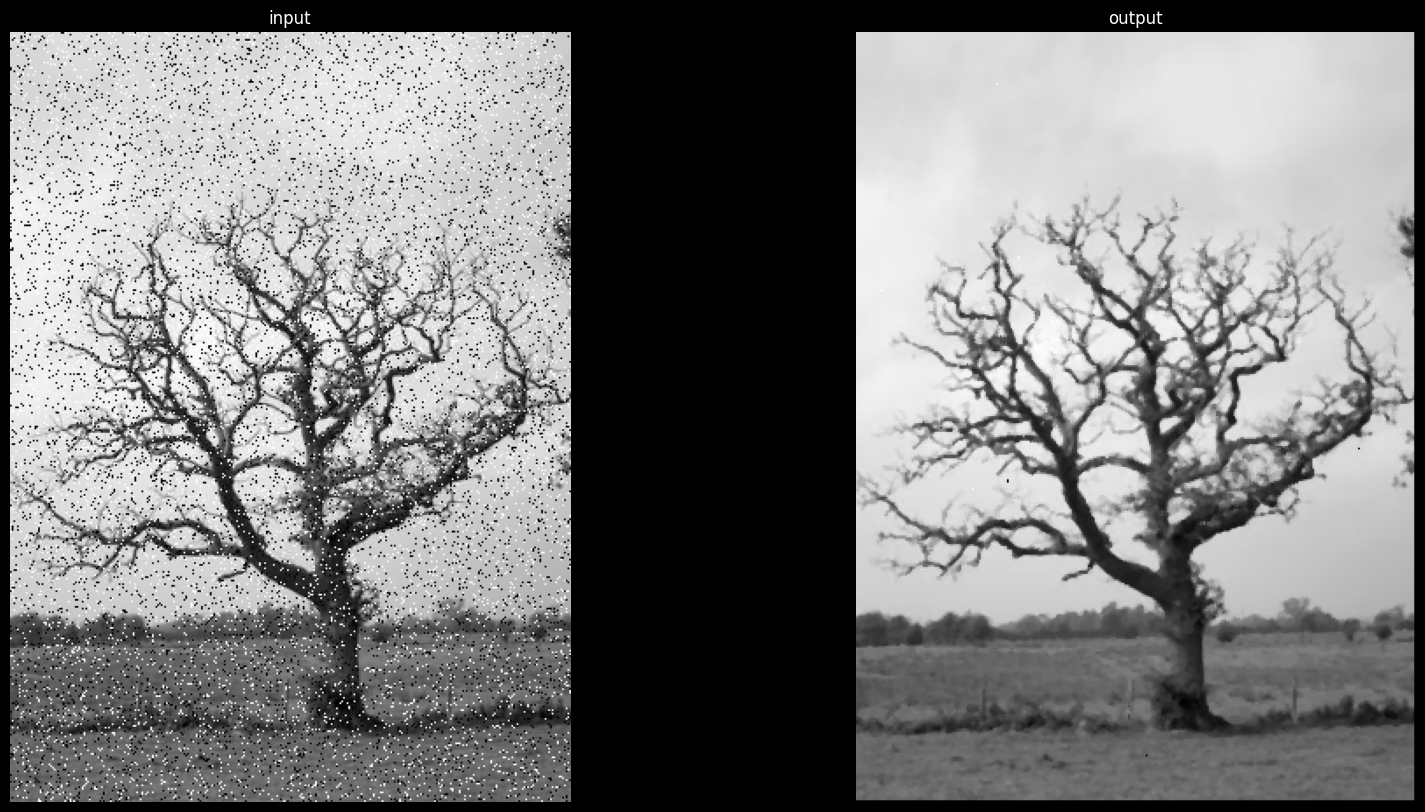

In [533]:
output = medianFilter(tree, 2, 1)

fig, axis = subplots(1,2, figsize=(20,10))
axis[0].imshow(tree, cmap='gray')
axis[0].axis('off')
axis[0].set_title('input')
axis[1].imshow(output, cmap='gray')
axis[1].axis('off')
axis[1].set_title('output')